# Testing Data Configs
This notebook tests different combinations of dataset config parameters (background subtraction, normalisation, resizing, split size) to find the optimal config for the Touch-EX dataset. This config will be saved in the configs directory for use in model building.

We will use the 'object' label for our classification models.

Note, at the time of running these tests the HuggingFace dataset only contained data for the first 6 objects, so these evaluations are running on a subset of the dataset.

In [43]:
# Allow imports from the parent directory
import sys
import os

module_path = os.path.abspath(os.path.join(".."))
sys.path.append(module_path)

In [44]:
# Imports
import json
import torch
from torch import optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from data.builder import get_dataloaders
from models.baseline import BaselineCNNModel
from models.pretrained import PretrainedModel
from models.train_eval import train_classifier, eval_classifier
from models.torch_functions import get_device

In [3]:
# Setup cuda
device = get_device()
device

device(type='cuda')

In [4]:
# Set random seed for reproducibility
torch.manual_seed(129)
torch.cuda.manual_seed_all(129)

## Testing Image Settings
We will start by testing the best combination of the following settings:

**Resize method:** Pad and then resize tactile images to 224x224 **OR** Centre-crop to 224x224.

**Normalisation:** Normalise tactile images using the train split mean and std **OR** don't normalise.

**Background subtraction:** Subtract the baseline.jpg image (DIGIT output when no contact with an object is made) **OR** no background substitution.

All combinations of these gives 8 different configurations.

#### Load Data

In [5]:
# Get default data config from json file
with open("../configs/default_data_config.json", "r", encoding="utf-8") as f:
    data_config = json.load(f)

In [6]:
# Create a list of data configs for each fold
# Start with default config and modify the fold-specific parameters for each fold
data_configs = [data_config.copy() for _ in range(8)]

In [7]:
# Update norm cache path for each fold as default path assumes we are in the root directory
# We are in the notebooks directory so we need to go up one level to access the cache file
for config in data_configs:
    config["norm_cache_path"] = "../configs/norm_cache.json"

In [8]:
# Set the path name for the baseline background image
BG_PATH = "../data/baseline.jpg"

In [9]:
# Define the different combinations of data config parameters to test
changes = [
    {"transform_name": "pad_224", "norm_type": None, "bg_path": None},
    {"transform_name": "pad_224", "norm_type": None, "bg_path": BG_PATH},
    {"transform_name": "pad_224", "norm_type": "dataset", "bg_path": None},
    {"transform_name": "pad_224", "norm_type": "dataset", "bg_path": BG_PATH},
    {"transform_name": "center_crop_224", "norm_type": None, "bg_path": None},
    {"transform_name": "center_crop_224", "norm_type": None, "bg_path": BG_PATH},
    {"transform_name": "center_crop_224", "norm_type": "dataset", "bg_path": None},
    {"transform_name": "center_crop_224", "norm_type": "dataset", "bg_path": BG_PATH},
]

In [10]:
# Define the titles for each data config combination
titles = [
    "pad_224_no_norm_no_bg",
    "pad_224_no_norm_bg",
    "pad_224_dataset_norm_no_bg",
    "pad_224_dataset_norm_bg",
    "center_crop_224_no_norm_no_bg",
    "center_crop_224_no_norm_bg",
    "center_crop_224_dataset_norm_no_bg",
    "center_crop_224_dataset_norm_bg",
]

In [11]:
# Update the data configs with the different combinations of parameters
for i in range(len(data_configs)):
    data_configs[i].update(changes[i])

In [12]:
# Get (dataloaders, label_info) tuples for each fold using the different data configs
data = [get_dataloaders(cfg) for cfg in data_configs]
# Split into dataloaders and label_info lists for easier access
dataloaders = [item[0] for item in data]
label_infos = [item[1] for item in data]

Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Norm cache found b

In [13]:
# Get the object labels from the first label_info (same for all)
object_labels = label_infos[0]["label2idx"]["object"].keys()
# Confirm number of classes
num_classes = len(object_labels)
num_classes

6

#### Training

In [14]:
# Define the model training configuration
model_config = {
    "optimizer": optim.Adam,
    "learning_rate": 0.001,
    "num_epochs": 4,
    "checkpoint_dir": "../checkpoints/test_data_configs",
    "model_title": "test_data_configs",
}

In [15]:
# Create a list of model configs for each fold
model_configs = [model_config.copy() for _ in range(8)]

In [16]:
# Update the model configs with the different titles for each fold
for i in range(len(model_configs)):
    model_configs[i]["model_title"] = titles[i]

In [17]:
# Train and validate the model for each fold using the corresponding dataloaders
models = []
histories = []

for i in range(len(dataloaders)):
    # Re-initialize the model for each fold
    model = BaselineCNNModel(num_classes=num_classes)
    # Train the model and save the history
    model, history = train_classifier(
        model=model,
        device=device,
        train_loader=dataloaders[i]["train"],
        val_loader=dataloaders[i]["val"],
        target_label="object",
        config=model_configs[i],
    )
    models.append(model)
    histories.append(history)

Starting training of pad_224_no_norm_no_bg on device: cuda
Epoch 1/4
Train Loss: 1.5929, Train Acc: 28.81%
Val Loss: 1.2086, Val Acc: 52.10%
Epoch 2/4
Train Loss: 0.4565, Train Acc: 83.05%
Val Loss: 1.1463, Val Acc: 66.56%
Epoch 3/4
Train Loss: 0.1678, Train Acc: 94.21%
Val Loss: 0.8645, Val Acc: 76.27%
Epoch 4/4
Train Loss: 0.1035, Train Acc: 96.51%
Val Loss: 1.0983, Val Acc: 77.19%
Loaded best model checkpoint from epoch 4.
Starting training of pad_224_no_norm_bg on device: cuda
Epoch 1/4
Train Loss: 0.2586, Train Acc: 89.75%
Val Loss: 0.7734, Val Acc: 84.85%
Epoch 2/4
Train Loss: 0.0252, Train Acc: 99.19%
Val Loss: 0.8186, Val Acc: 84.37%
Epoch 3/4
Train Loss: 0.0072, Train Acc: 99.77%
Val Loss: 0.9806, Val Acc: 84.86%
Epoch 4/4
Train Loss: 0.0212, Train Acc: 99.37%
Val Loss: 0.7828, Val Acc: 86.19%
Loaded best model checkpoint from epoch 4.
Starting training of pad_224_dataset_norm_no_bg on device: cuda
Epoch 1/4
Train Loss: 0.5411, Train Acc: 78.64%
Val Loss: 0.6296, Val Acc: 80.3

In [ ]:
# Convert histories to Pandas DataFrame
# Columns should start from 1 instead of 0 to match epoch numbers
histories_df = pd.DataFrame(
    histories, index=titles, columns=[f"epoch_{i + 1}" for i in range(len(histories[0]))]
)
# Save Dataframe to parquet file
histories_df.to_parquet("../results/test_data_configs/histories.parquet", index=True)

In [23]:
histories_df

,epoch_1,epoch_2,epoch_3,epoch_4
pad_224_no_norm_no_bg,"{'epoch': 1, 'train_loss': 1.592905516605512, ...","{'epoch': 2, 'train_loss': 0.45654993476995515...","{'epoch': 3, 'train_loss': 0.1678360790541989,...","{'epoch': 4, 'train_loss': 0.1034894466832928,..."
pad_224_no_norm_bg,"{'epoch': 1, 'train_loss': 0.25859063928317, '...","{'epoch': 2, 'train_loss': 0.02520572489212137...","{'epoch': 3, 'train_loss': 0.00718689597673695...","{'epoch': 4, 'train_loss': 0.02116394197276727..."
pad_224_dataset_norm_no_bg,"{'epoch': 1, 'train_loss': 0.5410814476080259,...","{'epoch': 2, 'train_loss': 0.11844575285027091...","{'epoch': 3, 'train_loss': 0.059746816923878, ...","{'epoch': 4, 'train_loss': 0.05273569134346683..."
pad_224_dataset_norm_bg,"{'epoch': 1, 'train_loss': 0.1452836377050373,...","{'epoch': 2, 'train_loss': 0.03038894726601828...","{'epoch': 3, 'train_loss': 0.01751113879040695...","{'epoch': 4, 'train_loss': 0.01541620307656551..."
center_crop_224_no_norm_no_bg,"{'epoch': 1, 'train_loss': 1.4666466217912202,...","{'epoch': 2, 'train_loss': 0.6022602689944846,...","{'epoch': 3, 'train_loss': 0.3424659347866924,...","{'epoch': 4, 'train_loss': 0.23689376978106658..."
center_crop_224_no_norm_bg,"{'epoch': 1, 'train_loss': 0.2673898388185503,...","{'epoch': 2, 'train_loss': 0.04625064256464609...","{'epoch': 3, 'train_loss': 0.02954572458484646...","{'epoch': 4, 'train_loss': 0.01997588571688641..."
center_crop_224_dataset_norm_no_bg,"{'epoch': 1, 'train_loss': 0.5366484280182452,...","{'epoch': 2, 'train_loss': 0.10801945311314898...","{'epoch': 3, 'train_loss': 0.071887446772376, ...","{'epoch': 4, 'train_loss': 0.04738308111482761..."
center_crop_224_dataset_norm_bg,"{'epoch': 1, 'train_loss': 0.20483147717777242...","{'epoch': 2, 'train_loss': 0.03107895365249212...","{'epoch': 3, 'train_loss': 0.02636130442482358...","{'epoch': 4, 'train_loss': 0.01583020419025321..."


#### Evaluation

In [50]:
# Evaluate the model for each fold on the test set
results = []
for i in range(len(dataloaders)):
    print(f"Evaluating model for data config: {titles[i]}...")
    model = models[i]
    result = eval_classifier(
        model=model,
        test_loader=dataloaders[i]["test"],
        target_label="object",
        device=device,
    )
    results.append(result)
    print("----")

Evaluating model for data config: pad_224_no_norm_no_bg...
Test Loss: 1.5451, Test Accuracy: 72.24%
Weighted F1 Average: 0.7178
----
Evaluating model for data config: pad_224_no_norm_bg...
Test Loss: 1.1783, Test Accuracy: 85.58%
Weighted F1 Average: 0.8550
----
Evaluating model for data config: pad_224_dataset_norm_no_bg...
Test Loss: 1.4844, Test Accuracy: 80.28%
Weighted F1 Average: 0.8063
----
Evaluating model for data config: pad_224_dataset_norm_bg...
Test Loss: 0.7341, Test Accuracy: 88.29%
Weighted F1 Average: 0.8829
----
Evaluating model for data config: center_crop_224_no_norm_no_bg...
Test Loss: 1.5427, Test Accuracy: 69.08%
Weighted F1 Average: 0.6848
----
Evaluating model for data config: center_crop_224_no_norm_bg...
Test Loss: 1.4177, Test Accuracy: 83.40%
Weighted F1 Average: 0.8340
----
Evaluating model for data config: center_crop_224_dataset_norm_no_bg...
Test Loss: 1.9970, Test Accuracy: 73.94%
Weighted F1 Average: 0.7415
----
Evaluating model for data config: cente

In [51]:
# Print classification report for each fold
for i, result in enumerate(results):
    print(f"{titles[i]}:")
    print(
        classification_report(
            result["y_true"], result["y_pred"], target_names=object_labels
        )
    )

pad_224_no_norm_no_bg:
              precision    recall  f1-score   support

       beans       0.58      0.67      0.62      1320
      hammer       0.62      0.91      0.73      1200
    pringles       0.64      0.65      0.64      1320
    scissors       0.84      0.43      0.57      1320
 tennis_ball       0.96      0.74      0.84      1320
 toilet_roll       0.86      0.95      0.90      1320

    accuracy                           0.72      7800
   macro avg       0.75      0.73      0.72      7800
weighted avg       0.75      0.72      0.72      7800

pad_224_no_norm_bg:
              precision    recall  f1-score   support

       beans       0.72      0.67      0.69      1320
      hammer       0.86      0.90      0.88      1200
    pringles       0.75      0.78      0.77      1320
    scissors       0.94      0.86      0.90      1320
 tennis_ball       0.96      0.94      0.95      1320
 toilet_roll       0.91      0.99      0.94      1320

    accuracy                      

In [52]:
# Convert test results to Pandas DataFrame
results_df = pd.DataFrame(results, index=titles)
# Save dataframe to parquet file
results_df.to_parquet("../results/test_data_configs/results.parquet", index=True)

In [53]:
results_df

,test_loss,test_acc,weighted_f1_avg,y_true,y_pred
pad_224_no_norm_no_bg,1.545146,72.243590,0.717824,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
pad_224_no_norm_bg,1.178336,85.576923,0.854968,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
pad_224_dataset_norm_no_bg,1.484385,80.282051,0.806253,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
pad_224_dataset_norm_bg,0.734057,88.294872,0.882936,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
center_crop_224_no_norm_no_bg,1.542657,69.076923,0.684828,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, ..."
center_crop_224_no_norm_bg,1.417683,83.397436,0.833987,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
center_crop_224_dataset_norm_no_bg,1.996960,73.935897,0.741523,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
center_crop_224_dataset_norm_bg,1.331233,81.641026,0.816219,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [54]:
# Save results without the y_true and y_pred columns to CSV for easy viewing
results_df.iloc[:, :3].to_csv("../results/test_data_configs/results.csv", index=True)

In [55]:
def plot_metrics(df, target_col, title):
    # Create a bar chart comparing the target metric for each data config
    df[[target_col]].plot(kind="bar", figsize=(12, 6))
    # Show titles with 'no_bg' in a different color
    for i, bar in enumerate(plt.gca().patches):
        if "no_bg" in titles[i]:
            bar.set_color("orange")
    # Configure, save and show the plot
    plt.title(f"{title} (orange bars indicate no_bg config)")
    plt.xlabel("Data Configuration")
    plt.ylabel(title)
    plt.xticks(rotation=45, ha="right")
    plt.legend().set_visible(False)  # Hide legend
    plt.tight_layout()
    plt.savefig(f"../results/test_data_configs/plots/{target_col}.png")
    plt.show()

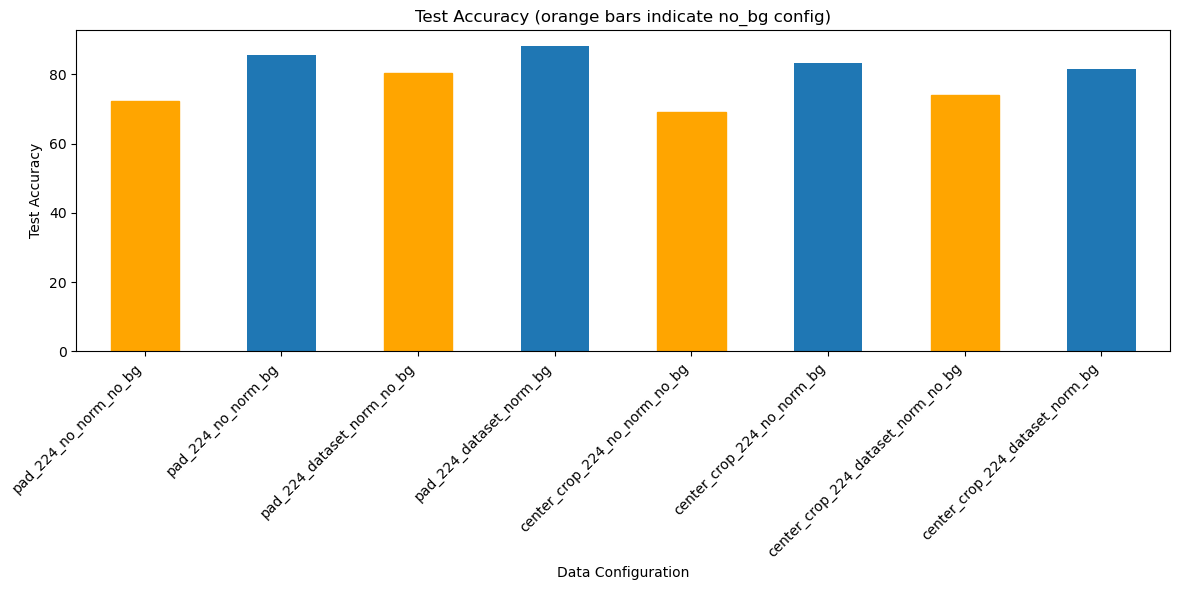

In [56]:
# Bar chart comparing the test accuracy for each fold
plot_metrics(results_df, "test_acc", "Test Accuracy")

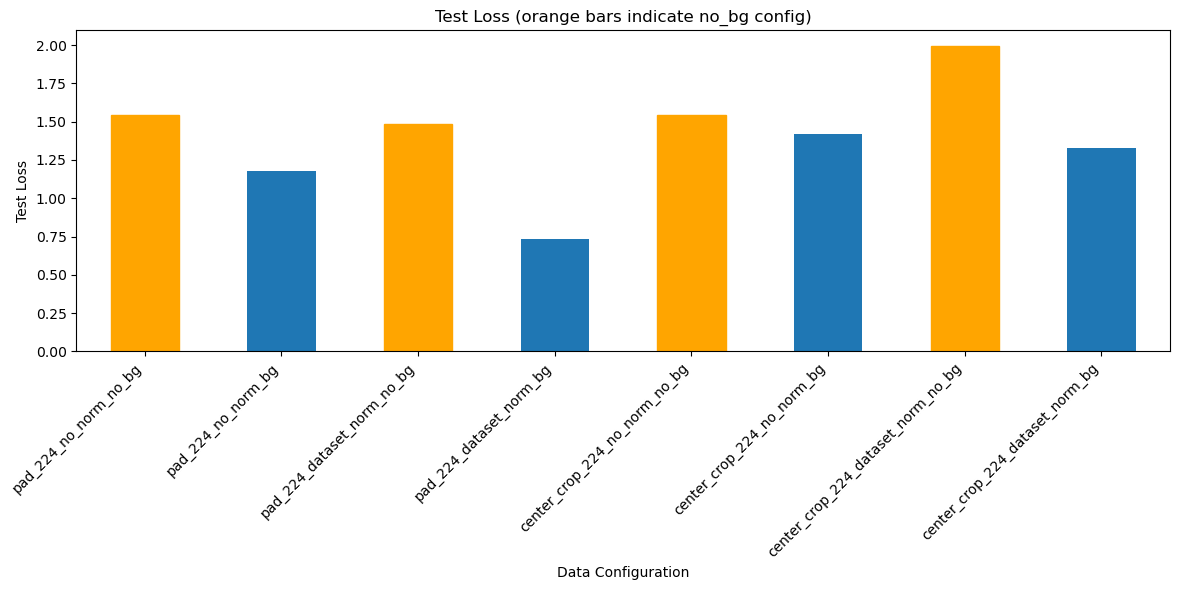

In [57]:
# Bar chart comparing the test loss for each fold
plot_metrics(results_df, "test_loss", "Test Loss")

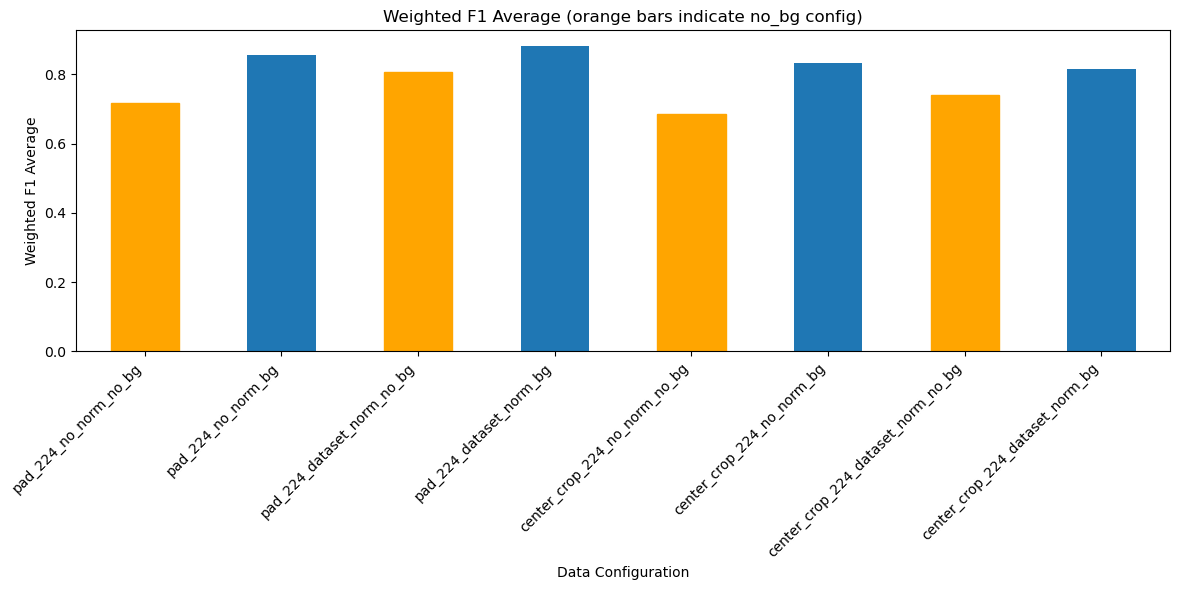

In [58]:
# Bar chart comparing the weighted F1 averages for each fold
plot_metrics(results_df, "weighted_f1_avg", "Weighted F1 Average")

#### Results
The best configuration was *pad_224_dataset_norm_bg*:

**Resize method:** Pad and then resize tactile images to 224x224. This makes sense because we would lose useful data from around the image edges when cropping.

**Normalisation:** Normalise tactile images using the train split mean and std.

**Background subtraction:** Subtract the baseline.jpg image (DIGIT output when no contact with an object is made). This helps remove sensor noise.

This configuration had the highest test accuracy (88.29%), weighted F1 average(0.88) and lowest test loss (0.73).

#### Updating Config File
Now we have our optimal set of paramaters, we can update the default_data_config.json file.

In [60]:
# Get best data config dictionary
best_config_index = titles.index("pad_224_dataset_norm_bg")
best_data_config = data_configs[best_config_index]
best_data_config

{'random_state': 129,
 'split_size': 0.3,
 'stratify_label': 'object',
 'transform_name': 'pad_224',
 'bg_path': '../data/baseline.jpg',
 'norm_type': 'dataset',
 'norm_cache_path': '../configs/norm_cache.json',
 'batch_size': 32,
 'shuffle_map': {'train': True, 'val': False, 'test': False}}

In [ ]:
# Reset bg_path and norm_cache_path to default values
best_data_config["bg_path"] = "data/baseline.jpg"
best_data_config["norm_cache_path"] = "configs/norm_cache.json"

In [61]:
# Overwrite the JSON file
with open("../configs/default_data_config.json", "w", encoding="utf-8") as f:
    json.dump(best_data_config, f, indent=4)

## Testing Random Cropping
Now we know that padding outperforms centre cropping, we can try random cropping to see if that outperforms padding (might possibly aid with overfitting).

#### Load Data

In [62]:
# Get default data config from json file
with open("../configs/default_data_config.json", "r", encoding="utf-8") as f:
    data_config = json.load(f)

In [63]:
# Update the transform name to random_crop_224 for this run
data_config["transform_name"] = "random_crop_224"
data_config

{'random_state': 129,
 'split_size': 0.3,
 'stratify_label': 'object',
 'transform_name': 'random_crop_224',
 'bg_path': '../data/baseline.jpg',
 'norm_type': 'dataset',
 'norm_cache_path': '../configs/norm_cache.json',
 'batch_size': 32,
 'shuffle_map': {'train': True, 'val': False, 'test': False}}

In [64]:
# Get the dataloaders
dataloaders, label_info = get_dataloaders(data_config)

Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.


In [65]:
# Get the object labels from the label_info
object_labels = label_info["label2idx"]["object"].keys()
# Confirm number of classes
num_classes = len(object_labels)
num_classes

6

#### Training

In [66]:
# Define the model training configuration
model_config = {
    "optimizer": optim.Adam,
    "learning_rate": 0.001,
    "num_epochs": 4,
    "checkpoint_dir": "../checkpoints/test_data_configs",
    "model_title": "random_crop_224_dataset_norm_bg",
}

In [67]:
# Initialise the model
model = BaselineCNNModel(num_classes=num_classes)
# Train the model and save the history
model, history = train_classifier(
    model=model,
    device=device,
    train_loader=dataloaders["train"],
    val_loader=dataloaders["val"],
    target_label="object",
    config=model_config,
)

Starting training of random_crop_224_dataset_norm_bg on device: cuda
Epoch 1/4
Train Loss: 0.3907, Train Acc: 85.15%
Val Loss: 0.8550, Val Acc: 76.45%
Epoch 2/4
Train Loss: 0.1158, Train Acc: 95.98%
Val Loss: 0.7175, Val Acc: 82.86%
Epoch 3/4
Train Loss: 0.0741, Train Acc: 97.52%
Val Loss: 0.8205, Val Acc: 82.28%
Epoch 4/4
Train Loss: 0.0559, Train Acc: 98.15%
Val Loss: 0.7213, Val Acc: 85.55%
Loaded best model checkpoint from epoch 4.


#### Evaluation

In [68]:
# Evaluate the model on the test set
results = eval_classifier(
    model=model, test_loader=dataloaders["test"], target_label="object", device=device
)

Test Loss: 0.9957, Test Accuracy: 83.72%
Weighted F1 Average: 0.8378


In [69]:
# Print classification report
print(
    classification_report(results["y_true"], results["y_pred"], target_names=object_labels)
)

              precision    recall  f1-score   support

       beans       0.69      0.75      0.72      1320
      hammer       0.77      0.87      0.82      1200
    pringles       0.79      0.75      0.77      1320
    scissors       0.87      0.75      0.80      1320
 tennis_ball       0.99      0.93      0.96      1320
 toilet_roll       0.94      0.98      0.96      1320

    accuracy                           0.84      7800
   macro avg       0.84      0.84      0.84      7800
weighted avg       0.84      0.84      0.84      7800



#### Results
pad_224 results vs random_crop_224 results: 

**Test accuracy:** 88.29% vs 83.72%

**Test loss:** 0.73 vs 1.00

**F1 score:** 0.88 vs 0.84

The padding version outperforms the random crop version in all metrics, thereore we will keep padding as the chosen transform.

## Testing Dataset Split
Now we can check if splitting 80/20 instead of 70/30 improves results.

#### Load Data

In [73]:
# Get default data config from json file
with open("../configs/default_data_config.json", "r", encoding="utf-8") as f:
    data_config = json.load(f)

In [74]:
# Update split to 80/20
data_config["split_size"] = 0.2
data_config

{'random_state': 129,
 'split_size': 0.2,
 'stratify_label': 'object',
 'transform_name': 'pad_224',
 'bg_path': '../data/baseline.jpg',
 'norm_type': 'dataset',
 'norm_cache_path': '../configs/norm_cache.json',
 'batch_size': 32,
 'shuffle_map': {'train': True, 'val': False, 'test': False}}

In [75]:
# Get the dataloaders
dataloaders, label_info = get_dataloaders(data_config)

Dataframe split into following sizes:
Train: 41400, Val: 5160, Test: 5280
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.


In [76]:
# Get the object labels from the label_info
object_labels = label_info["label2idx"]["object"].keys()
# Confirm number of classes
num_classes = len(object_labels)
num_classes

6

#### Training

In [77]:
# Define the model training configuration
model_config = {
    "optimizer": optim.Adam,
    "learning_rate": 0.001,
    "num_epochs": 4,
    "checkpoint_dir": "../checkpoints/test_data_configs",
    "model_title": "split_80_20",
}

In [78]:
# Initialise the model
model = BaselineCNNModel(num_classes=num_classes)
# Train the model and save the history
model, history = train_classifier(
    model=model,
    device=device,
    train_loader=dataloaders["train"],
    val_loader=dataloaders["val"],
    target_label="object",
    config=model_config,
)

Starting training of split_80_20 on device: cuda
Epoch 1/4
Train Loss: 0.1381, Train Acc: 95.29%
Val Loss: 0.7269, Val Acc: 85.62%
Epoch 2/4
Train Loss: 0.0186, Train Acc: 99.47%
Val Loss: 0.7298, Val Acc: 86.03%
Epoch 3/4
Train Loss: 0.0257, Train Acc: 99.24%
Val Loss: 0.9589, Val Acc: 83.24%
Epoch 4/4
Train Loss: 0.0155, Train Acc: 99.62%
Val Loss: 0.9782, Val Acc: 84.07%
Loaded best model checkpoint from epoch 2.


#### Evaluation

In [79]:
# Evaluate the model on the test set
results = eval_classifier(
    model=model, test_loader=dataloaders["test"], target_label="object", device=device
)

Test Loss: 0.9547, Test Accuracy: 82.50%
Weighted F1 Average: 0.8240


In [80]:
# Print classification report
print(
    classification_report(results["y_true"], results["y_pred"], target_names=object_labels)
)

              precision    recall  f1-score   support

       beans       0.71      0.68      0.70       960
      hammer       0.87      0.93      0.90       840
    pringles       0.69      0.68      0.69       840
    scissors       0.89      0.86      0.87       840
 tennis_ball       0.95      0.89      0.92       840
 toilet_roll       0.84      0.92      0.88       960

    accuracy                           0.82      5280
   macro avg       0.83      0.83      0.83      5280
weighted avg       0.82      0.82      0.82      5280



#### Results
70/30 results vs 80/20 results: 

**Test accuracy:** 88.29% vs 82.50%

**Test loss:** 0.73 vs 0.95

**F1 score:** 0.88 vs 0.82

The 70/30 version outperforms the 80/20 version in all metrics, thereore we will keep 70/30 as the chosen dataset split.

## Testing ImageNet Normalisation
The last thing we want to test is whether using the ImageNet normalisation values outperforms using the dataset normalisation values, when using a pre-trained ImageNet backbone.

For this we will use a pretrained ImageNet ResNet CNN and run it with both types of normalisation to compare. ImageNet normalisation is usually recommended when using pretrained models, but as tactile images are so different from standard RGB images, it is probable that dataset normalisation works best.

#### Load Data

In [81]:
# Get default data config from json file
with open("../configs/default_data_config.json", "r", encoding="utf-8") as f:
    data_config = json.load(f)

In [82]:
# Create a new config for imagenet normalisation
data_config_2 = data_config.copy()
data_config_2["norm_type"] = "imagenet"
data_config_2

{'random_state': 129,
 'split_size': 0.3,
 'stratify_label': 'object',
 'transform_name': 'pad_224',
 'bg_path': '../data/baseline.jpg',
 'norm_type': 'imagenet',
 'norm_cache_path': '../configs/norm_cache.json',
 'batch_size': 32,
 'shuffle_map': {'train': True, 'val': False, 'test': False}}

In [84]:
# Get (dataloaders, label_info) tuples for each fold using the different data configs
data_configs = [data_config, data_config_2]
data = [get_dataloaders(cfg) for cfg in data_configs]
# Split into dataloaders and label_info lists for easier access
dataloaders = [item[0] for item in data]
label_infos = [item[1] for item in data]

Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Loading imagenet normalisation stats.


In [85]:
# Get the object labels from the first label_info (same for all)
object_labels = label_infos[0]["label2idx"]["object"].keys()
# Confirm number of classes
num_classes = len(object_labels)
num_classes

6

#### Training

In [86]:
# Define the model training configuration
model_config = {
    "optimizer": optim.Adam,
    "learning_rate": 0.001,
    "num_epochs": 4,
    "checkpoint_dir": "../checkpoints/test_data_configs",
    "model_title": "resnet",
}

In [87]:
# Create a list of model configs for each fold
model_configs = [model_config.copy() for _ in range(2)]
# Update the model configs with the different titles for each fold
model_configs[0]["model_title"] = "resnet_dataset_norm"
model_configs[1]["model_title"] = "resnet_imagenet_norm"

In [88]:
# Train and validate the model for each fold using the corresponding dataloaders
models = []
histories = []

for i in range(len(dataloaders)):
    # Re-initialize the model for each fold
    model = PretrainedModel(model_type="resnet", num_classes=num_classes)
    # Train the model and save the history
    model, history = train_classifier(
        model=model,
        device=device,
        train_loader=dataloaders[i]["train"],
        val_loader=dataloaders[i]["val"],
        target_label="object",
        config=model_configs[i],
    )
    models.append(model)
    histories.append(history)

Starting training of resnet_dataset_norm on device: cuda
Epoch 1/4
Train Loss: 0.1409, Train Acc: 94.94%
Val Loss: 0.4566, Val Acc: 84.82%
Epoch 2/4
Train Loss: 0.0352, Train Acc: 98.78%
Val Loss: 0.2192, Val Acc: 93.32%
Epoch 3/4
Train Loss: 0.0272, Train Acc: 99.14%
Val Loss: 0.2281, Val Acc: 94.90%
Epoch 4/4
Train Loss: 0.0220, Train Acc: 99.36%
Val Loss: 0.1527, Val Acc: 95.08%
Loaded best model checkpoint from epoch 4.
Starting training of resnet_imagenet_norm on device: cuda
Epoch 1/4
Train Loss: 0.1441, Train Acc: 94.88%
Val Loss: 0.3267, Val Acc: 89.32%
Epoch 2/4
Train Loss: 0.0408, Train Acc: 98.65%
Val Loss: 0.4867, Val Acc: 91.09%
Epoch 3/4
Train Loss: 0.0301, Train Acc: 99.00%
Val Loss: 0.8832, Val Acc: 81.29%
Epoch 4/4
Train Loss: 0.0219, Train Acc: 99.34%
Val Loss: 0.3223, Val Acc: 92.17%
Loaded best model checkpoint from epoch 4.


#### Evaluation

In [89]:
# Evaluate the model for each fold on the test set
results = []
for i in range(len(dataloaders)):
    print(f"Evaluating {model_configs[i]['model_title']}...")
    model = models[i]
    result = eval_classifier(
        model=model,
        test_loader=dataloaders[i]["test"],
        target_label="object",
        device=device,
    )
    results.append(result)
    print("----")

Evaluating resnet_dataset_norm...
Test Loss: 0.5461, Test Accuracy: 89.01%
Weighted F1 Average: 0.8892
----
Evaluating resnet_imagenet_norm...
Test Loss: 0.5182, Test Accuracy: 88.10%
Weighted F1 Average: 0.8798
----


In [90]:
# Print classification report for each fold
for i, result in enumerate(results):
    print(f"{model_configs[i]['model_title']}:")
    print(
        classification_report(
            result["y_true"], result["y_pred"], target_names=object_labels
        )
    )

resnet_dataset_norm:
              precision    recall  f1-score   support

       beans       0.83      0.74      0.78      1320
      hammer       0.89      0.86      0.88      1200
    pringles       0.84      0.89      0.86      1320
    scissors       0.82      0.88      0.85      1320
 tennis_ball       0.96      1.00      0.98      1320
 toilet_roll       0.99      0.98      0.99      1320

    accuracy                           0.89      7800
   macro avg       0.89      0.89      0.89      7800
weighted avg       0.89      0.89      0.89      7800

resnet_imagenet_norm:
              precision    recall  f1-score   support

       beans       0.83      0.69      0.75      1320
      hammer       0.90      0.86      0.88      1200
    pringles       0.78      0.94      0.85      1320
    scissors       0.86      0.85      0.85      1320
 tennis_ball       1.00      0.94      0.97      1320
 toilet_roll       0.94      1.00      0.97      1320

    accuracy                      

#### Results
Although dataset normalisation slightly outperforms the Imagenet normalisation, the gains are very marginal. Therefore, it may be preferable to use Imagenet normalisation because of the saving in computational cost (no need to calculate mean and std from thousands of images). We will leave the default_data_config.json file with the existing dataset normalisation parameter (used with baesline CNNs anyway), but can manually update it to use Imagenet normalisation as and when required.